# Convolutional Neural Network: 
## Food Recognition

In [198]:
import numpy as np
from pathlib import Path
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

from copy import deepcopy

# Progress bar
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torchvision import datasets, transforms

import tensorboard as tb
from torch.utils.tensorboard import SummaryWriter

In [199]:
%reload_ext tensorboard

## CNN Structure:

In [ ]:
def kaiming_init(m):

    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if m.bias is not None:
            nn.init.zeros_(m.bias)

    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        nn.init.zeros_(m.bias)

    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),

            nn.Linear(256, 80)
        )

    def forward(self, x):
        return self.net(x)

    @property
    def device(self):
        """
        Returns the device on which the model is. Can be useful in some situations.
        """
        return next(self.parameters()).device

### Seed

In [201]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): # GPU operation have separate seed
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

# Additionally, some operations on a GPU are implemented stochastic for efficiency
# We want to ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


### Evaluation

In [202]:
def eval_model(model, data_loader):
    model.eval()
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(model.device)
            targets = targets.to(model.device)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            total_correct += (preds == targets).sum().item()
            total_samples += targets.size(0)

    return total_correct / total_samples

### Analyze Data

Train total items: 30612
Test total items: 7653
Train images: 30612
Test images: 7653


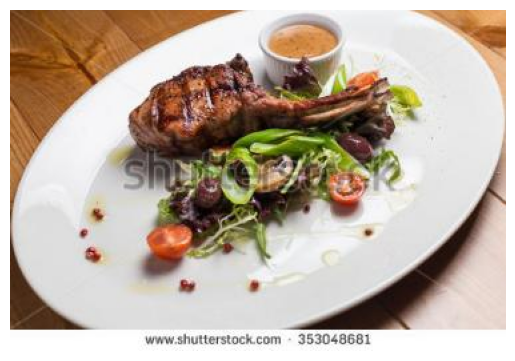

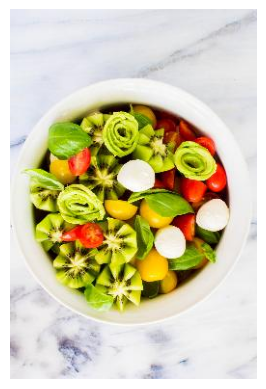

In [203]:
# Creating paths
ROOT = Path("food-recognition-challenge-2026")

TRAIN_DIR = ROOT / "train_set"
TEST_DIR  = ROOT / "test_set"
TRAIN_CSV = ROOT / "train_labels.csv"
CLASS_TXT = ROOT / "class_list_food.txt"

# Unpacking the lists of images
train_files = list(TRAIN_DIR.rglob("*.jpg"))
test_files  = list(TEST_DIR.rglob("*"))

# Unpacking the images out of the list
img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
train_imgs = [p for p in TRAIN_DIR.rglob("*") if p.suffix.lower() in img_exts]
test_imgs  = [p for p in TEST_DIR.rglob("*") if p.suffix.lower() in img_exts]

# Amount of images
print("Train total items:", len(train_files))
print("Test total items:", len(test_files))
print("Train images:", len(train_imgs))
print("Test images:", len(test_imgs))

# Showing images
for i in range(2):
    image = Image.open(train_files[i])
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [204]:
import pandas as pd

# Head of train_labels csv
df = pd.read_csv(TRAIN_CSV)
print(df.head())


      img_name  label
0  train_1.jpg     21
1  train_2.jpg     29
2  train_3.jpg     17
3  train_4.jpg     21
4  train_5.jpg     50


In [205]:
# Creating classes from class_list_food.txt
classes = dict()

with open(CLASS_TXT, 'r') as c:
    for i in c:
        i = i.strip()
        if not i:
            continue

        k, v = i.split(' ', 1)
        classes[k] = v

# Amount of classes
print(len(classes))

80


In [206]:
sizes = []

for p in train_imgs:
    with Image.open(p) as im:
        sizes.append(im.size)         # (width, height)

print("Example sizes:", sizes[:10])

ws = [w for (w,h) in sizes]
hs = [h for (w,h) in sizes]
print("Width min/max:", min(ws), max(ws))
print("Height min/max:", min(hs), max(hs))


Example sizes: [(372, 256), (256, 384), (384, 256), (340, 256), (379, 256), (314, 256), (383, 256), (256, 341), (667, 256), (454, 256)]
Width min/max: 256 1920
Height min/max: 256 2744


In [207]:
from sklearn.model_selection import train_test_split

train_label, val_label = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
)

print(len(train_label), len(val_label))

24489 6123


In [208]:
from torch.utils.data import Dataset
from PIL import Image

class FoodDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]["img_name"]
        label = self.img_labels.iloc[idx]["label"] - 1

        img_path = self.img_dir / img_name
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [209]:
from torchvision import transforms
from torch.utils.data import DataLoader

IMG_SIZE = 64
BATCH_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

validation_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = FoodDataset(TRAIN_CSV, TRAIN_DIR, transform=train_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

validation_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

### Training

In [ ]:
def train_model(model, train_loader, test_loader, epochs, seed, lr, device,
    data_dir="runs/FRC-Challenge"):

    # seed for reproducability
    set_seed(seed)
    # tensorboard
    writer = SummaryWriter(data_dir)
    model_plotted = False

    # loss module and optimizer
    loss_module = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # initializing best tracking
    best_val_acc = -1.0
    best_epoch = -1
    best_model = deepcopy(model)

    # Start epoch
    for epoch in tqdm(range(epochs)):
        model.train()

        running_loss = 0.0
        total_correct = 0
        total_samples = 0

        for inputs, targets in train_loader:
            # push to device
            inputs = inputs.to(device)
            targets = targets.to(device)

            # set gradient to nothing
            optimizer.zero_grad()

            # forward
            logits = model(inputs)
            loss = loss_module(logits, targets)

            # backward + update
            loss.backward()
            optimizer.step()

            # stats
            running_loss += loss.item()

            # predictions is the output of the system
            preds = logits.argmax(dim=1)
            total_correct += (preds == targets).sum().item()
            total_samples += targets.size(0)

        # epoch metrics (outside batch loop!)
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = total_correct / total_samples

        # write to tensorboard
        writer.add_scalar("Loss/train", epoch_loss, epoch)
        writer.add_scalar("Accuracy/train", epoch_acc, epoch)

        # validation
        val_acc = eval_model(model, test_loader)  # uses no_grad + eval inside
        writer.add_scalar("Accuracy/val", val_acc, epoch)
        print(f"Epoch {epoch+1}/{epochs} | loss={epoch_loss:.4f} | train_acc={epoch_acc:.4f} | val_acc={val_acc:.4f}")

        # checkpoint
        """torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
        }, "checkpoint.pth") """

        # track best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model = deepcopy(model)

    # Test best model
    best_test_acc = eval_model(best_model, test_loader)
    writer.add_scalar("Accuracy/best_test", best_test_acc, epochs)
    print("Best test accuracy:", best_test_acc)

    writer.close()

    torch.save(best_model.state_dict(), "best_model.pth")

In [214]:
model = CNN().to(device)

train_model(model=model,
            train_loader=train_loader,
            test_loader=validation_loader,
            device=device,
            epochs=5,
            seed=42,
            lr=1e-3)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 | loss=4.4234 | train_acc=0.0316 | val_acc=0.0434
Epoch 2/5 | loss=4.1448 | train_acc=0.0472 | val_acc=0.0480
Epoch 3/5 | loss=4.0453 | train_acc=0.0498 | val_acc=0.0525
Epoch 4/5 | loss=3.9978 | train_acc=0.0512 | val_acc=0.0525


KeyboardInterrupt: 

In [ ]:
%tensorboard --logdir runs/FRC-Challenge

Reusing TensorBoard on port 6006 (pid 43484), started 1:41:21 ago. (Use '!kill 43484' to kill it.)